# Week-7, Part-1: Inception Module, Micro/Mini GoogleNet, for Image Classification.

### Welcome to the 7th Lab of 42028: Deep Learning and CNN!

In this  Lab/Tutorial session you will be implementing Inception module and create a Convolutional Neural Network for image classification .

So lets get started!

## Tutorial:
Implementation of Inception based Micro-GoogleNet CNN architecture using Keras for classfication of Cifar-10 dataset.

## Tasks for this week:

1. Implementation of Inception based Mini-GoogleNet CNN architecture for Cifar-10 classification using Keras API.
2. Train and test model


**Reference and adapted from:** [https://www.analyticsvidhya.com/blog/2018/10/understanding-inception-network-from-scratch/](https://www.analyticsvidhya.com/blog/2018/10/understanding-inception-network-from-scratch/)

## The Inception Begins !

### Step 1: Import required packages

we will need tensorflow, numpy, os and keras


In [4]:
# Install OpenCV library
!pip install opencv-python-headless

In [5]:
!pip install pydot

In [6]:
!nvidia-smi

Mon Mar 30 01:17:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   29C    P8              9W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Fix for GPU Compilation Error (libdevice not found)

**What this does:** This sets a system environment variable (`XLA_FLAGS`) to explicitly tell TensorFlow's XLA compiler the correct base directory (`/opt/conda`) to search for CUDA libraries.

**Why it is needed:**
To train efficiently on a GPU, TensorFlow uses an optimizing compiler called XLA. XLA requires a specific CUDA file named `libdevice.10.bc` to compile the graph. In many custom or cloud-based Conda environments, this file is located outside of TensorFlow's default search paths, which causes `model.fit()` to crash with an `InternalError`. By manually pointing to the correct directory, we prevent the crash and enable hardware acceleration.

In [7]:
!find / -type f -name "libdevice.10.bc" 2>/dev/null

/opt/conda/lib/python3.12/site-packages/triton/backends/nvidia/lib/libdevice.10.bc
/opt/conda/nvvm/libdevice/libdevice.10.bc


In [8]:
import os
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/opt/conda'

In [9]:
import keras
from keras.layers import Layer
import keras.backend as K
import tensorflow as tf

from keras.models import Model
from keras.layers import Conv2D, MaxPool2D,  \
    Dropout, Dense, Input, concatenate,      \
    GlobalAveragePooling2D, AveragePooling2D,\
    Flatten

import cv2
import numpy as np
from keras.datasets import cifar10
from keras import backend as K
from keras import utils
#from keras.utils import np_utils

import math
from keras.optimizers import SGD
from keras.callbacks import LearningRateScheduler

2026-03-30 01:17:09.616685: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-30 01:17:09.630260: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774833429.648346    1133 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774833429.653902    1133 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-30 01:17:09.671771: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

### Step-2: Design the Inception V1 module





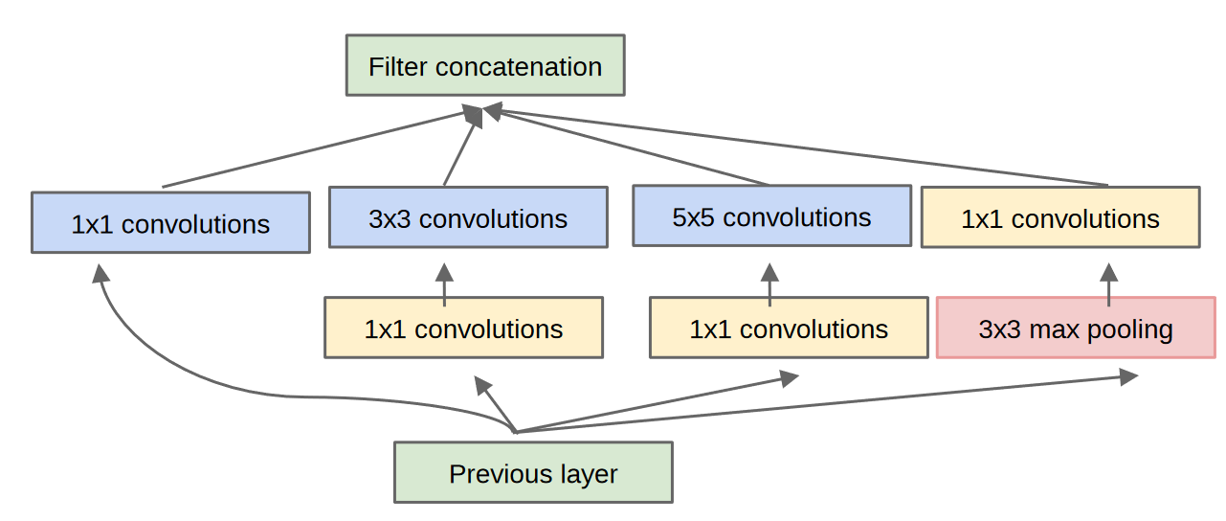

In [10]:
# Create the Inception module
def inception_module(x,
                     filters_1x1,
                     filters_3x3_reduce,
                     filters_3x3,
                     filters_5x5_reduce,
                     filters_5x5,
                     filters_pool_proj,
                     name=None):

    # 1X1 CONV
    conv_1x1 = Conv2D(filters_1x1, (1, 1), padding='same', activation='relu', kernel_initializer=kernel_init, bias_initializer=bias_init)(x)

    # 1X1 CONV --> 3x3 CONV
    conv_3x3 = Conv2D(filters_3x3_reduce, (1, 1), padding='same', activation='relu', kernel_initializer=kernel_init, bias_initializer=bias_init)(x)
    conv_3x3 = Conv2D(filters_3x3, (3, 3), padding='same', activation='relu', kernel_initializer=kernel_init, bias_initializer=bias_init)(conv_3x3)

    # 1X1 CONV --> 5x5 CONV
    conv_5x5 = Conv2D(filters_5x5_reduce, (1, 1), padding='same', activation='relu', kernel_initializer=kernel_init, bias_initializer=bias_init)(x)
    conv_5x5 = Conv2D(filters_5x5, (5, 5), padding='same', activation='relu', kernel_initializer=kernel_init, bias_initializer=bias_init)(conv_5x5)

    # 3X3 MAXPOOL --> 1X1 CONV
    pool_proj = MaxPool2D((3, 3), strides=(1, 1), padding='same')(x)
    pool_proj = Conv2D(filters_pool_proj, (1, 1), padding='same', activation='relu', kernel_initializer=kernel_init, bias_initializer=bias_init)(pool_proj)

    # Concatenate the layers
    output = concatenate([conv_1x1, conv_3x3, conv_5x5, pool_proj], axis=3, name=name)

    return output

In [11]:
kernel_init = keras.initializers.glorot_uniform()
bias_init = keras.initializers.Constant(value=0.2)

### Step 3: Design a Micro-GoogleNet with 1 Layer of Inception V1


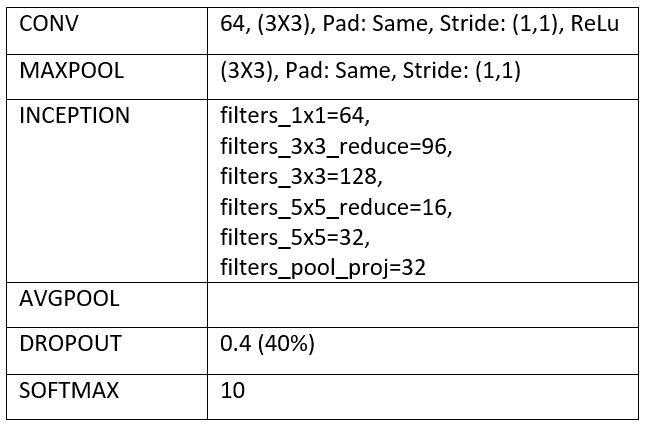

In [12]:
# Create the input layer
input_layer = Input(shape=(32, 32, 3)) # Use the actual input size

# CONV Layer
x = Conv2D(64, (3, 3), padding='same', strides=(1, 1), activation='relu', name='conv_1_3x3-2', kernel_initializer=kernel_init, bias_initializer=bias_init)(input_layer)
x = MaxPool2D((3, 3), padding='same', strides=(1, 1), name='max_pool_1_3x3-2')(x)

#Adding Inception layer to te modeel
x = inception_module(x,
                     filters_1x1=64,
                     filters_3x3_reduce=96,
                     filters_3x3=128,
                     filters_5x5_reduce=16,
                     filters_5x5=32,
                     filters_pool_proj=32,
                     name='inception_3a')

x = GlobalAveragePooling2D(name='avg_pool_5_3x3-1')(x)

x = Dropout(0.1)(x)

x = Dense(10, activation='softmax', name='output')(x)

I0000 00:00:1774833435.108617    1133 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13764 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [13]:
# Form the model
model = Model(input_layer, x, name='inception_v1')

In [14]:
#Display Model Summary
model.summary()

Model: "inception_v1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1_3x3-2        │ (None, 32, 32,    │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool_1_3x3-2    │ (None, 32, 32,    │          0 │ conv_1_3x3-2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      6,240 │ max_pool_1_3x3-2… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      1,040 │ max_pool_1_3x3-2… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ max_pool_1_3x3-2… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      4,160 │ max_pool_1_3x3-2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    110,720 │ conv2d_1[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     12,832 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      2,080 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a        │ (None, 32, 32,    │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 256)              │            │ conv2d_2[0][0],   │
│                     │                   │            │ conv2d_4[0][0],   │
│                     │                   │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg_pool_5_3x3-1    │ (None, 256)       │          0 │ inception_3a[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ avg_pool_5_3x3-1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 10)        │      2,570 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 141,434 (552.48 KB)

 Trainable params: 141,434 (552.48 KB)

 Non-trainable params: 0 (0.00 B)

### Visualize the Micro-GoogleNet Architecture

1. Using plot_model from keras.utils

**Requires**: pydot, pydotplus, graphviz (Available on Google Colab already, installation not required)

*   pip install pydot
*   pip install pydotplus
* pip install graphviz



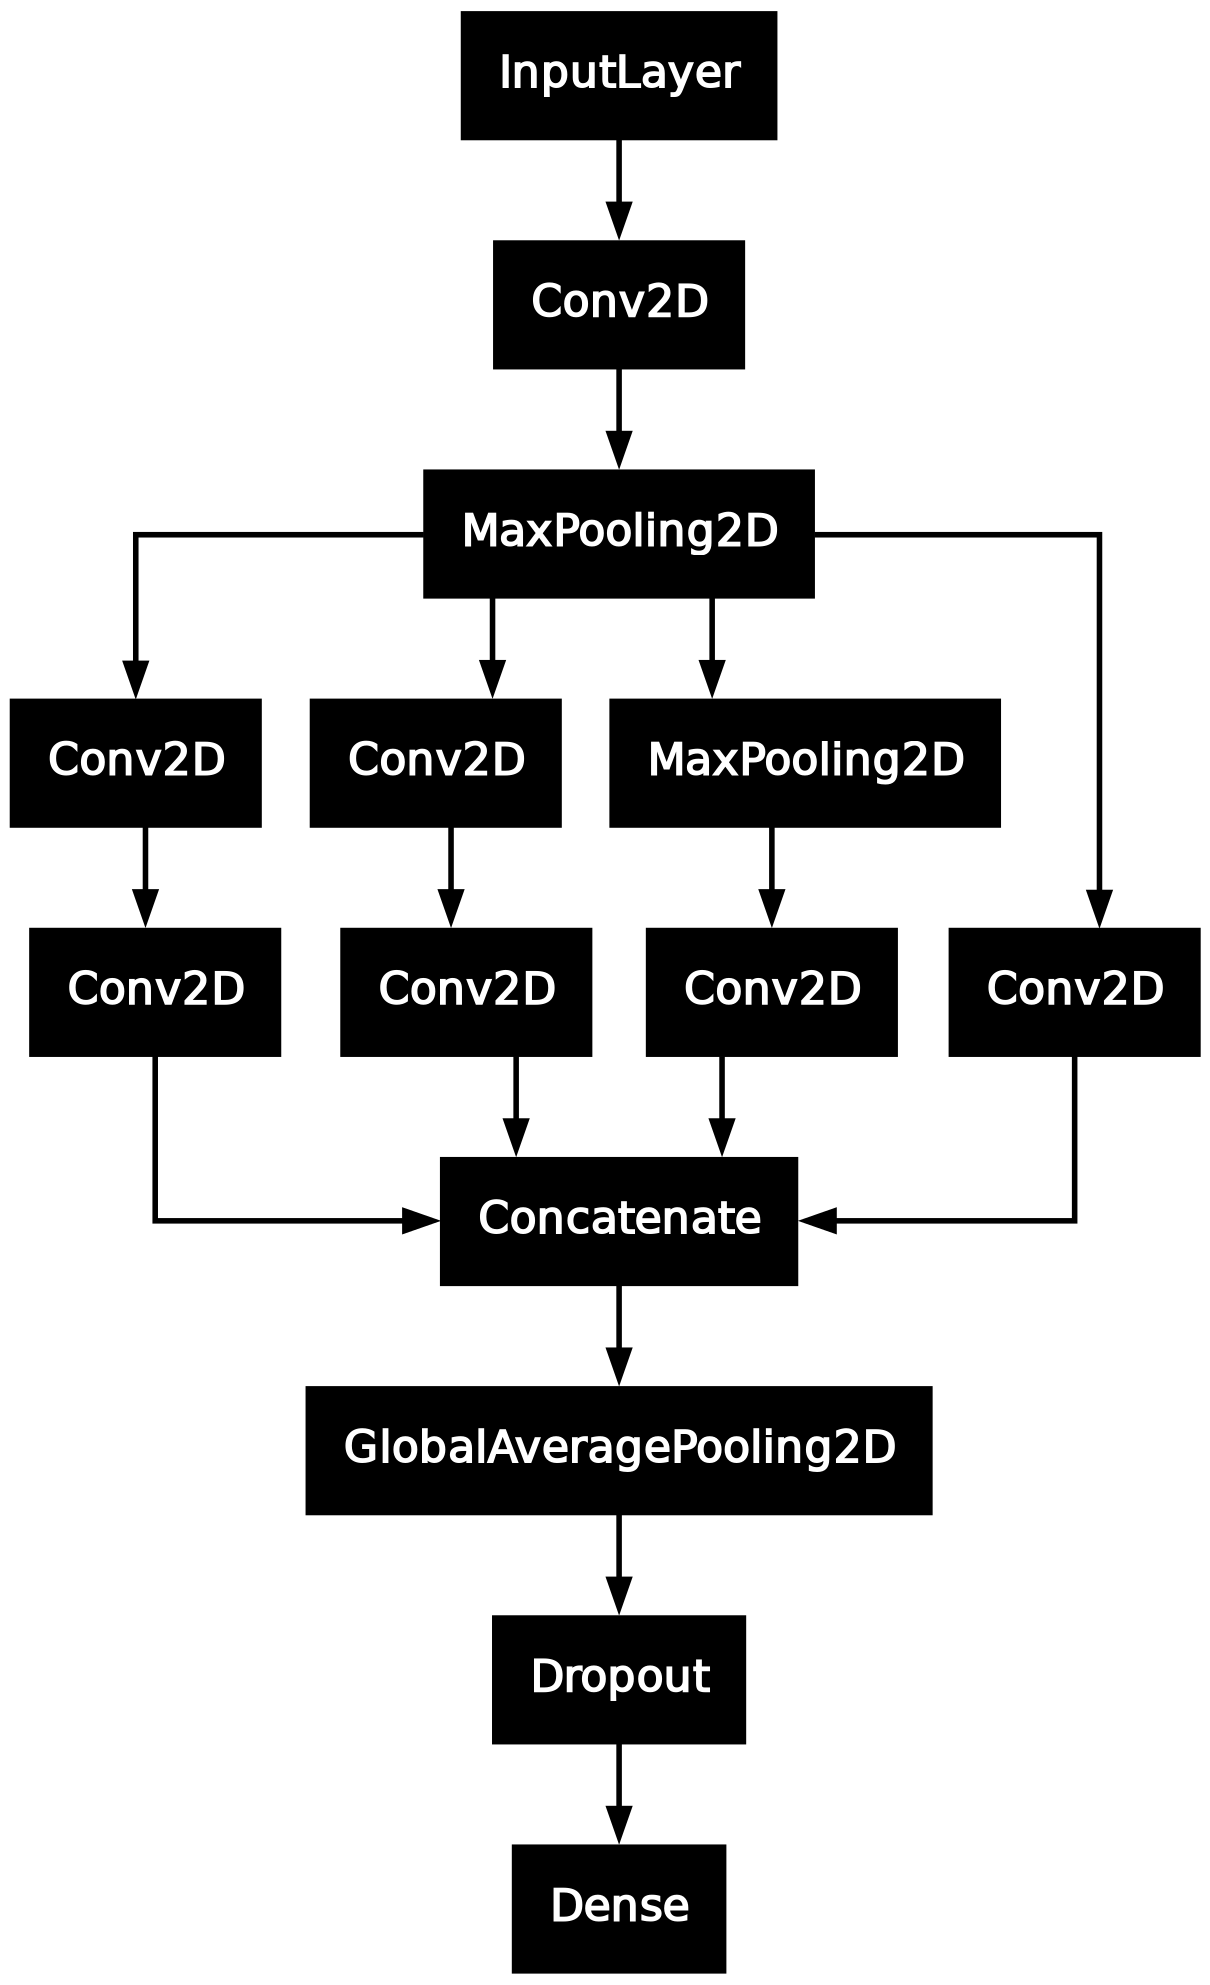

In [15]:
# Using Plot_Model from Keras.Utils
model_img_file = 'MicroGNet-model.png'
tf.keras.utils.plot_model(model, to_file=model_img_file,
                          show_shapes=False,
                          show_layer_activations=False,
                          show_dtype=False,
                          show_layer_names=False )

# Also Try:
# show_shapes=True, show_layer_activations=True, show_dtype=True, show_layer_names=True

2. Using VisualKeras library:

The keras.utils.vis_utils provides utility functions to plot a Keras model using Graphviz.

In [16]:
model.summary()

Model: "inception_v1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1_3x3-2        │ (None, 32, 32,    │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool_1_3x3-2    │ (None, 32, 32,    │          0 │ conv_1_3x3-2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      6,240 │ max_pool_1_3x3-2… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      1,040 │ max_pool_1_3x3-2… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ max_pool_1_3x3-2… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      4,160 │ max_pool_1_3x3-2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    110,720 │ conv2d_1[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     12,832 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      2,080 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a        │ (None, 32, 32,    │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 256)              │            │ conv2d_2[0][0],   │
│                     │                   │            │ conv2d_4[0][0],   │
│                     │                   │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg_pool_5_3x3-1    │ (None, 256)       │          0 │ inception_3a[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ avg_pool_5_3x3-1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 10)        │      2,570 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 141,434 (552.48 KB)

 Trainable params: 141,434 (552.48 KB)

 Non-trainable params: 0 (0.00 B)

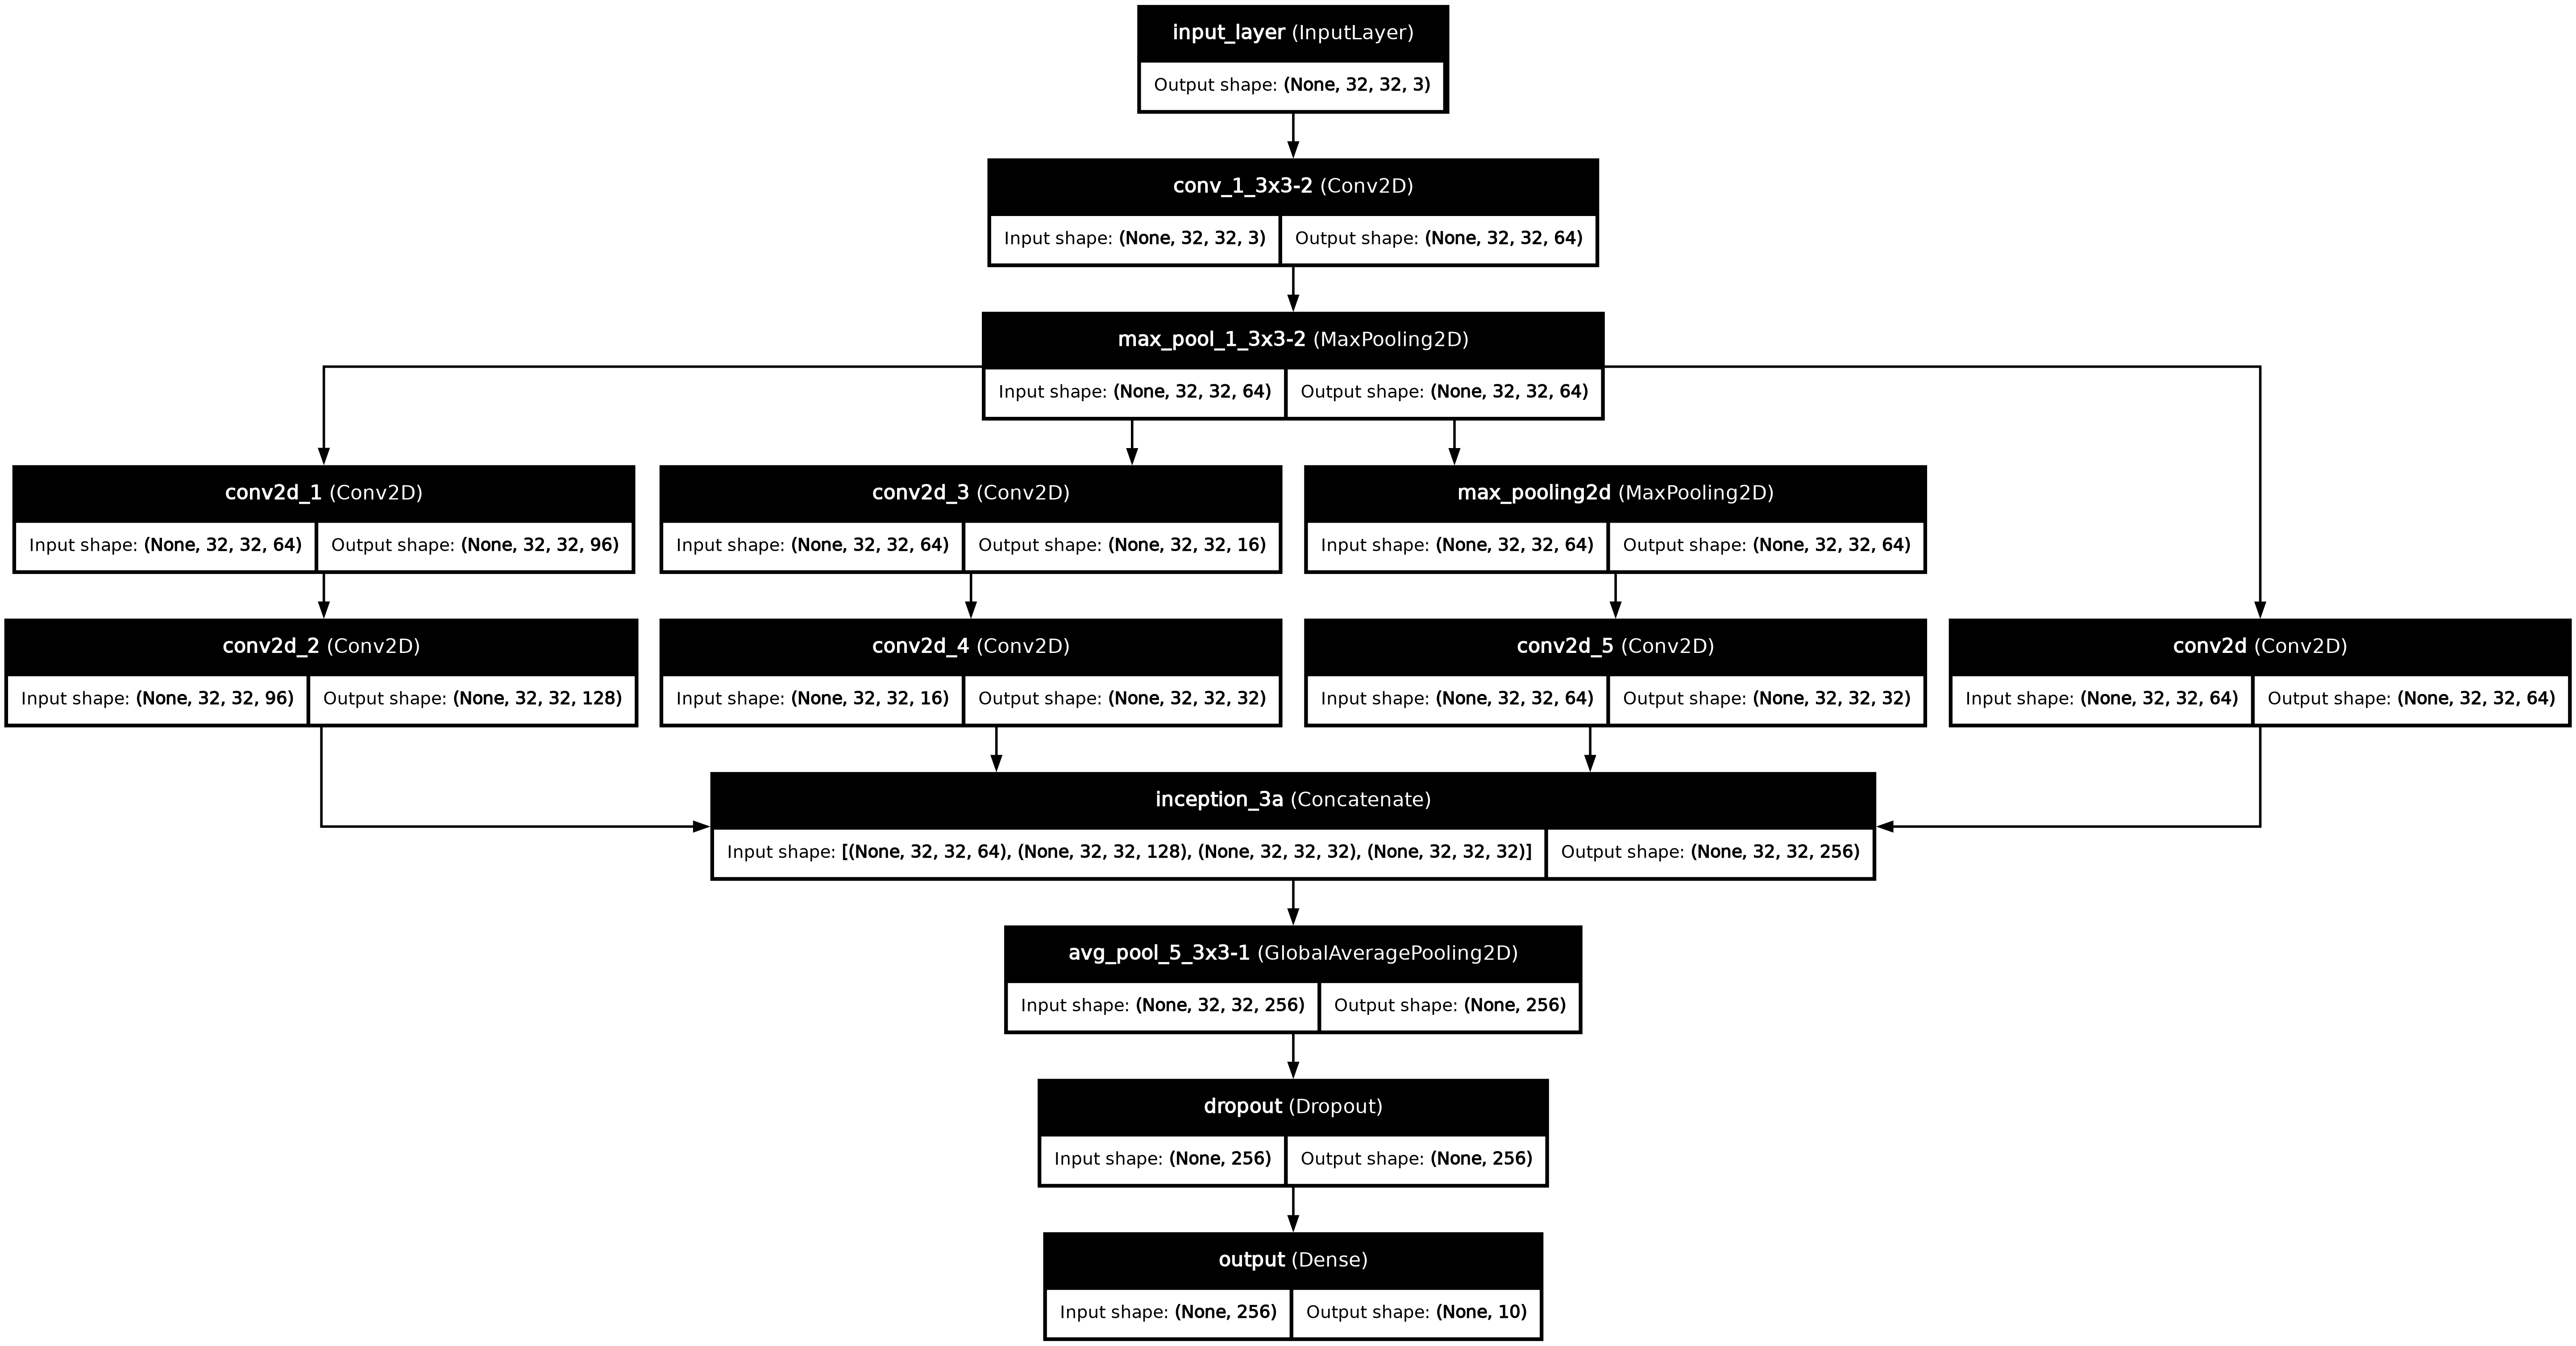

In [17]:
!pip install visualkeras==0.0.2

from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

### Step 4: Download the Cifar-10 dataset using keras

In [18]:
num_classes = 10 #Number of classes in the dataset
from keras.utils import to_categorical

def load_cifar10_data(img_rows, img_cols):

    # Load cifar10 training and validation sets
    (X_train, Y_train), (X_valid, Y_valid) = keras.datasets.cifar10.load_data() #cifar10.load_data()

    # Resize training images
    X_train = np.array([cv2.resize(img, (img_rows,img_cols)) for img in X_train[:,:,:,:]])
    X_valid = np.array([cv2.resize(img, (img_rows,img_cols)) for img in X_valid[:,:,:,:]])

    # Transform targets to keras compatible format
    Y_train = to_categorical(Y_train, num_classes)
    Y_valid = to_categorical(Y_valid, num_classes)

    X_train = X_train.astype('float32')
    X_valid = X_valid.astype('float32')

    # preprocess data
    X_train = X_train / 255.0
    X_valid = X_valid / 255.0

    return X_train, Y_train, X_valid, Y_valid

In [19]:
# Display the shapes of the training images
#(X_train, y_train), (X_test, y_test) = load_cifar10_data(32, 32)


X_train, y_train, X_test, y_test = load_cifar10_data(32, 32)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


/opt/conda/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 10)
(10000, 10)


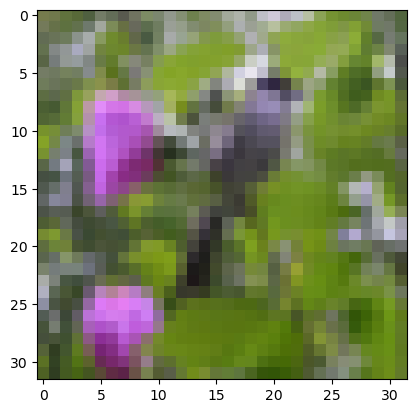

In [20]:
## Display an image from the dataset
import matplotlib.pyplot as plt
plt.imshow(X_train[300])

### Step 5: Define the Hyper-parameters, Compile the model, Start training

In [21]:
#Define the number of epochs and learning rate
epochs = 25
initial_lrate = 0.001

#Create Learning rate decay
def decay(epoch, steps=100):
    initial_lrate = 0.01
    drop = 0.96
    epochs_drop = 8
    lrate = initial_lrate * math.pow(drop, math.floor((1+epoch)/epochs_drop))
    return lrate

#Define SGD paramenters
sgd = SGD(learning_rate=initial_lrate, momentum=0.9, nesterov=False)

lr_sc = LearningRateScheduler(decay, verbose=1)

## Compile Model
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])


In [22]:
#Start training the model
history1 = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=64, callbacks=[lr_sc])


Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/25


I0000 00:00:1774833482.985300    1338 service.cc:148] XLA service 0x7f196c00efd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774833482.985343    1338 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-03-30 01:18:03.018633: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774833483.141203    1338 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-30 01:18:03.460414: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,64,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,3,32,32]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation

 13/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.1020 - loss: 2.3577

I0000 00:00:1774833486.822280    1338 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


778/782 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1818 - loss: 2.1629

2026-03-30 01:18:18.616712: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,64,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,32,32]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2026-03-30 01:18:18.676090: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,128,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,96,32,32]{3,2,1,0}, f32[128,96,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1820 - loss: 2.1623

2026-03-30 01:18:21.420069: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,64,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,3,32,32]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2026-03-30 01:18:21.528978: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,128,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,96,32,32]{3,2,1,0}, f32[128,96,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.2285 - loss: 2.0426 - val_accuracy: 0.2742 - val_loss: 1.9760 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.01.
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3101 - loss: 1.8054 - val_accuracy: 0.3471 - val_loss: 1.7132 - learning_rate: 0.0100

Epoch 3: LearningRateScheduler setting learning rate to 0.01.
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3508 - loss: 1.7095 - val_accuracy: 0.3893 - val_loss: 1.6401 - learning_rate: 0.0100

Epoch 4: LearningRateScheduler setting learning rate to 0.01.
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3813 - loss: 1.6544 - val_accuracy: 0.4240 - val_loss: 1.5819 - learning_rate: 0.0100

Epoch 5: LearningRateScheduler setting learning rate to 0.01.
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.4106 - loss: 1.5917 - val_accuracy: 0.3892 - val_loss: 1.6831 - learning_ra

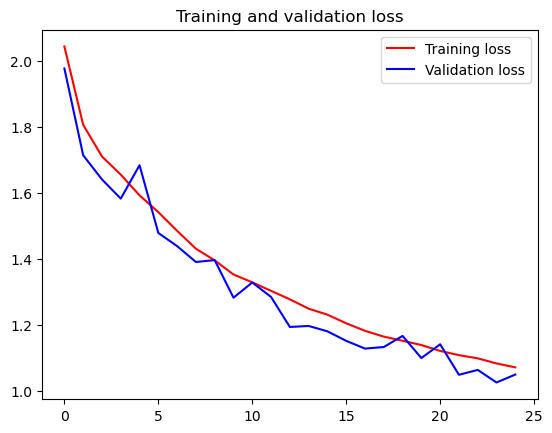

In [23]:
## Plot the Traning and Validation loss
loss = history1.history['loss']
val_loss = history1.history['val_loss']

epochs = range(len(loss))

plt.figure()

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

## Your task begins now!

## Task 1: Design a Mini-GoogleNet with Inception V1 model

### Add four inception layers in the Micro-GoogleNet architecture created above in the following order and configuration:



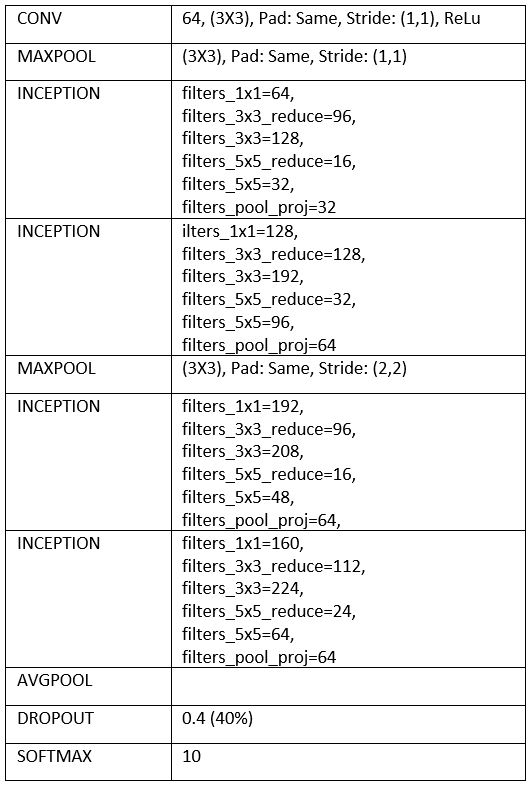

In [24]:
# Define the input layer
input_layer = Input(shape=(32, 32, 3))

# Add the first CONV layer and MaxPOOL layer
x = Conv2D(64, (3, 3), padding='same', strides=(1, 1), activation='relu', name='conv_1_3x3-2', kernel_initializer=kernel_init, bias_initializer=bias_init)(input_layer)
x = MaxPool2D((3, 3), padding='same', strides=(1, 1), name='max_pool_1_3x3-2')(x)

## Add Inception layer-1
x = inception_module(x,
                     filters_1x1=64,
                     filters_3x3_reduce=96,
                     filters_3x3=128,
                     filters_5x5_reduce=16,
                     filters_5x5=32,
                     filters_pool_proj=32,
                     name='inception_3a')

## Add Inception layer-2
x = inception_module(x,
                     filters_1x1=128,
                     filters_3x3_reduce=128,
                     filters_3x3=192,
                     filters_5x5_reduce=32,
                     filters_5x5=96,
                     filters_pool_proj=64,
                     name='inception_3b')

## Add MaxPool
x = MaxPool2D((3, 3), padding='same', strides=(2, 2), name='max_pool_3_3x3-2')(x)

## Add Inception layer-3
x = inception_module(x,
                     filters_1x1=192,
                     filters_3x3_reduce=96,
                     filters_3x3=208,
                     filters_5x5_reduce=16,
                     filters_5x5=48,
                     filters_pool_proj=64,
                     name='inception_4a')

## Add Inception layer-4
x = inception_module(x,
                     filters_1x1=160,
                     filters_3x3_reduce=112,
                     filters_3x3=224,
                     filters_5x5_reduce=24,
                     filters_5x5=64,
                     filters_pool_proj=64,
                     name='inception_4b')

x = GlobalAveragePooling2D(name='avg_pool_5_3x3-1')(x)

x = Dropout(0.4)(x)

x = Dense(10, activation='softmax', name='output')(x)

In [25]:
# Form the Model
model = Model(input_layer, x, name='inception_v1')

In [26]:
# Print Model Summary
model.summary()

Model: "inception_v1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1_3x3-2        │ (None, 32, 32,    │      1,792 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool_1_3x3-2    │ (None, 32, 32,    │          0 │ conv_1_3x3-2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │      6,240 │ max_pool_1_3x3-2… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │      1,040 │ max_pool_1_3x3-2… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ max_pool_1_3x3-2… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │      4,160 │ max_pool_1_3x3-2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    110,720 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │     12,832 │ conv2d_9[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │      2,080 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a        │ (None, 32, 32,    │          0 │ conv2d_6[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_8[0][0],   │
│                     │                   │            │ conv2d_10[0][0],  │
│                     │                   │            │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 32,    │     32,896 │ inception_3a[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 32, 32,    │      8,224 │ inception_3a[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ inception_3a[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32,    │     32,896 │ inception_3a[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 32, 32,    │    221,376 │ conv2d_13[0][0]   │
│                     │ 192)              │            │                 

 Total params: 1,358,066 (5.18 MB)

 Trainable params: 1,358,066 (5.18 MB)

 Non-trainable params: 0 (0.00 B)

## Task 2: Define the HyperParamenters, Optimzer, etc

In [27]:
#Define the number of epochs and learning rate
epochs = 25
initial_lrate = 0.01

#Create Learning rate decay
def decay(epoch, steps=100):
    initial_lrate = 0.01
    drop = 0.96
    epochs_drop = 8
    lrate = initial_lrate * math.pow(drop, math.floor((1+epoch)/epochs_drop))
    return lrate

#Define SGD paramenters
sgd = SGD(learning_rate=initial_lrate, momentum=0.9, nesterov=False)

lr_sc = LearningRateScheduler(decay, verbose=1)

## Task 3: Compile and Train the Model

In [28]:
# Compile the model and start training
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=64, callbacks=[lr_sc])


Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/25


2026-03-30 01:25:41.229037: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,192,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,128,32,32]{3,2,1,0}, f32[192,128,3,3]{3,2,1,0}, f32[192]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2026-03-30 01:25:41.737794: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,96,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,32,32,32]{3,2,1,0}, f32[96,32,5,5]{3,2,1,0}, f32[96]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActi

781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1722 - loss: 2.1714

2026-03-30 01:26:47.464597: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,192,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,32,32]{3,2,1,0}, f32[192,128,3,3]{3,2,1,0}, f32[192]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2026-03-30 01:26:47.649917: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,96,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,32,32,32]{3,2,1,0}, f32[96,32,5,5]{3,2,1,0}, f32[96]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActi

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.1723 - loss: 2.1712

2026-03-30 01:26:54.480954: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,192,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,128,32,32]{3,2,1,0}, f32[192,128,3,3]{3,2,1,0}, f32[192]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2026-03-30 01:26:54.998153: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,96,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,32,32,32]{3,2,1,0}, f32[96,32,5,5]{3,2,1,0}, f32[96]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActi

782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 93ms/step - accuracy: 0.2235 - loss: 2.0237 - val_accuracy: 0.3101 - val_loss: 1.7892 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.01.
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.3587 - loss: 1.6995 - val_accuracy: 0.4387 - val_loss: 1.5477 - learning_rate: 0.0100

Epoch 3: LearningRateScheduler setting learning rate to 0.01.
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.4351 - loss: 1.5110 - val_accuracy: 0.4943 - val_loss: 1.3751 - learning_rate: 0.0100

Epoch 4: LearningRateScheduler setting learning rate to 0.01.
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.4998 - loss: 1.3561 - val_accuracy: 0.4931 - val_loss: 1.3597 - learning_rate: 0.0100

Epoch 5: LearningRateScheduler setting learning rate to 0.01.
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.5416 - loss: 1.2491 - val_accuracy: 0.5721 - val_loss: 1.1644 - learning_ra

## Task 4: Test on Train and Test set

In [29]:
# Test the model on Test and Validationa dataset
model.evaluate(X_train, y_train)
model.evaluate(X_test, y_test)

2026-03-30 01:51:23.703053: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,32,32]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2026-03-30 01:51:23.766968: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,128,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,96,32,32]{3,2,1,0}, f32[128,96,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8684 - loss: 0.3813
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8042 - loss: 0.5747


[0.5747199654579163, 0.8041999936103821]

## Task 5: Display the Train and Validation Loss curve

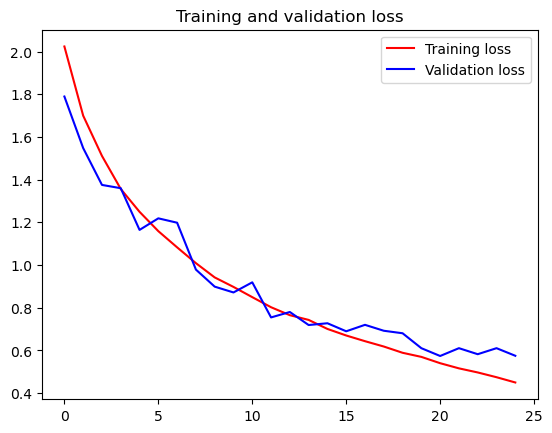

In [30]:
# Display the train and validation loss
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(loss))

plt.figure()

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

### 5. Visualize the CNN Architechture

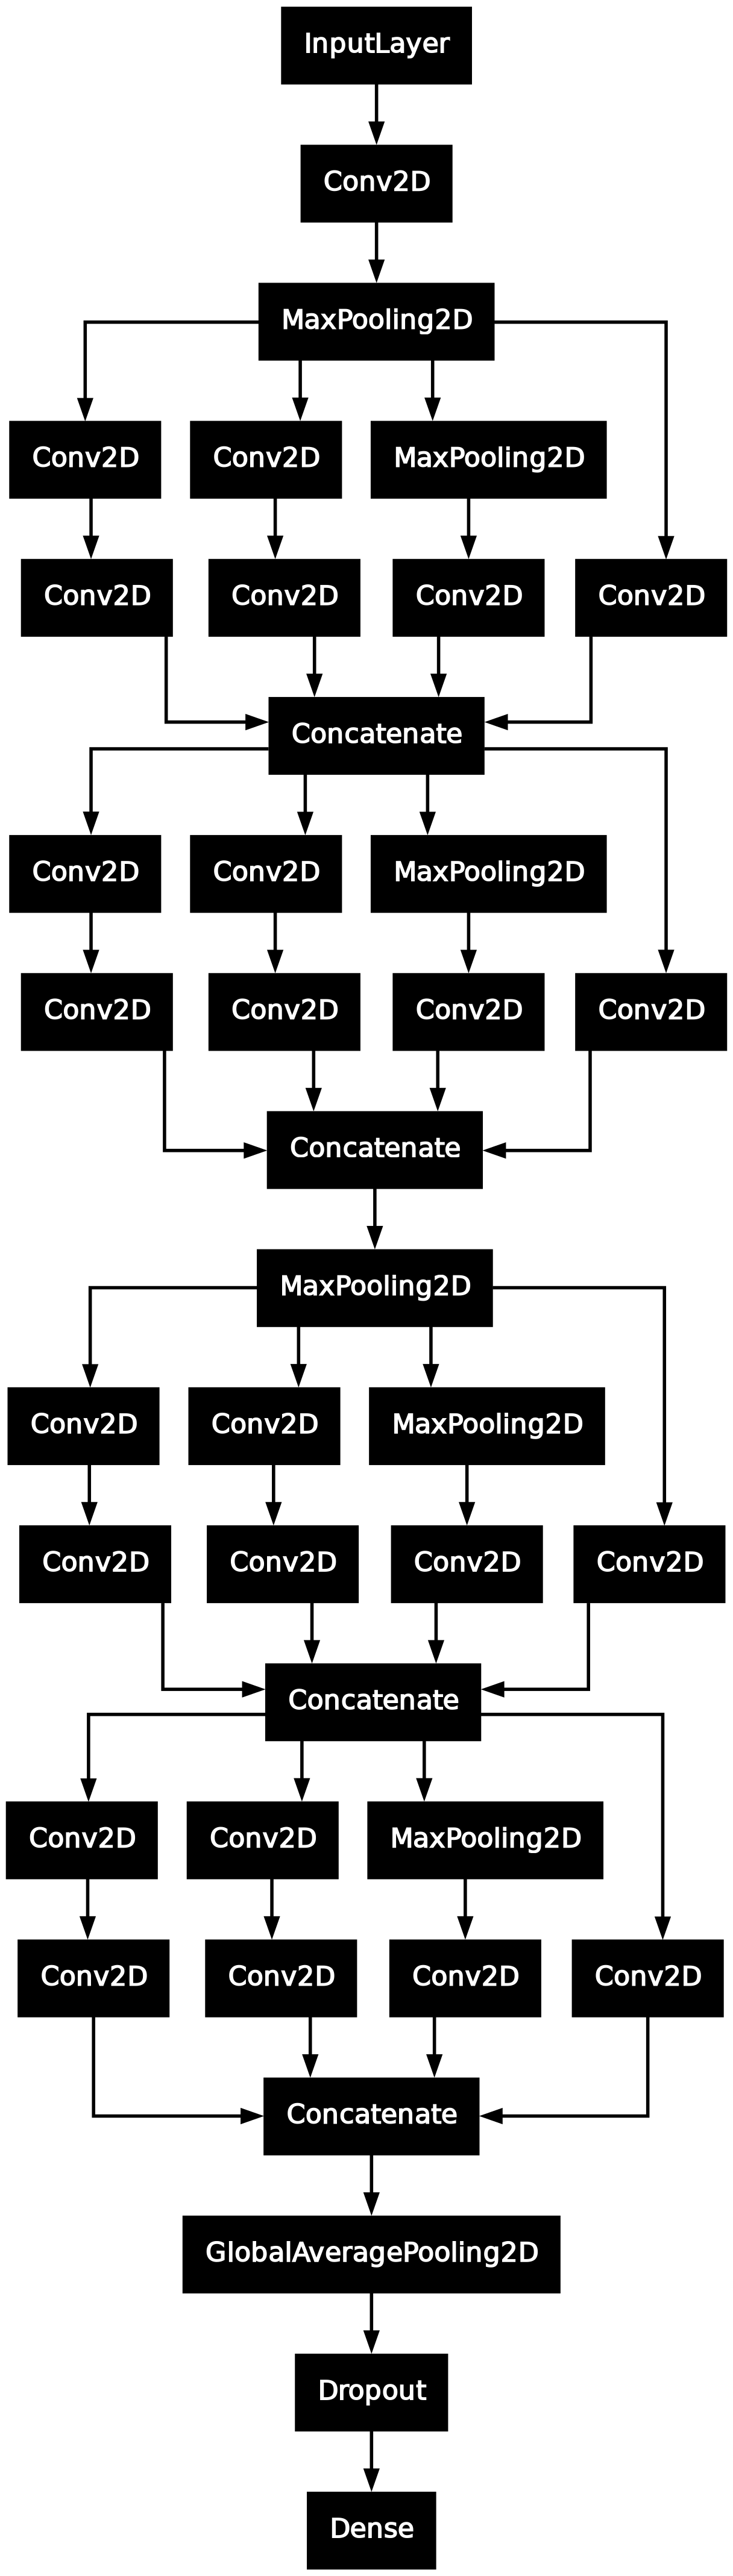

In [31]:
model_img_file = 'MiniGNet-model.png'
tf.keras.utils.plot_model(model, to_file=model_img_file,
                          show_shapes=False,
                          show_layer_activations=False,
                          show_dtype=False,
                          show_layer_names=False )

# Visualize Keras Sequential Model using ann_visulizer

In [33]:
pip install ann_visualizer

Note: you may need to restart the kernel to use updated packages.


In [34]:
# Import Library
from ann_visualizer.visualize import ann_viz

In [35]:
# Create a simple ANN architecture
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 72, 72, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 36, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 165888)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │   169,870,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 170,564,609 (650.65 MB)

 Trainable params: 170,564,609 (650.65 MB)

 Non-trainable params: 0 (0.00 B)

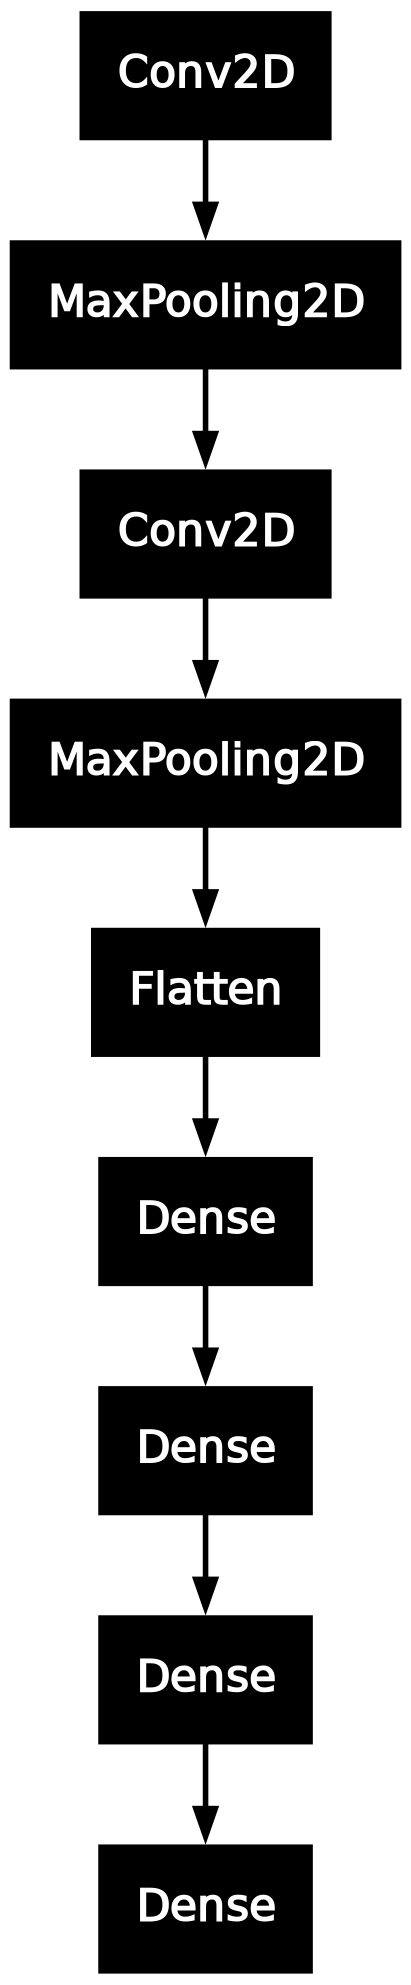

In [37]:
model_img_file = 'Sequential-model.png'
tf.keras.utils.plot_model(model, to_file=model_img_file,
                          show_shapes=False,
                          show_layer_activations=False,
                          show_dtype=False,
                          show_layer_names=False )